# Практична робота №4: Дослідження дерев рішень та ансамблевих методів у задачі багатокласової класифікації за наявності пропущених значень

**Мета роботи:**
Дослідити та порівняти три алгоритми класифікації — дерево рішень (Decision Tree), випадковий ліс (Random Forest) та градієнтний бустинг (XGBoost) — на реальному датасеті Annealing, що містить пропущені значення. Основну увагу приділити:

* впливу способу обробки пропусків на якість класифікації;
* коректному (без витоку даних) підбору гіперпараметрів за допомогою Optuna;
* неупередженому оцінюванню моделей (вкладена крос-валідація) та статистичному порівнянню результатів;
* інтерпретації моделей і розбіжностей між їхніми прогнозами (permutation importance, SHAP).


# Датасет: Annealing

**Характеристики датасету:**
- **Цільова змінна:** class - категорія сталі
- **Кількість спостережень:** 898 (OpenML)
- **Ознаки:** 38 ознак, з них 32 категоріальні та 6 числові

In [1]:
SEED = 42 + 25

import os
import warnings
from typing import cast

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml

warnings.filterwarnings(
    "ignore", message="Skipping features without any observed values"
)
warnings.filterwarnings("ignore", category=UserWarning)

script_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
data_dir = os.path.join(script_dir, "data")
plots_dir = os.path.join(script_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

## Етап 1. Завантаження датасету та EDA

In [2]:

data = fetch_openml(name="anneal", version=1, as_frame=True)
X, y = data.data, data.target

print("Shapes:", X.shape, y.shape)

feat_df = cast(pd.DataFrame, X)
target_df = cast(pd.Series, y)

Shapes: (898, 38) (898,)


### Характеристики ознак

In [3]:
feat_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   family                        126 non-null    category
 1   product-type                  898 non-null    category
 2   steel                         812 non-null    category
 3   carbon                        898 non-null    int64   
 4   hardness                      898 non-null    int64   
 5   temper_rolling                137 non-null    category
 6   condition                     595 non-null    category
 7   formability                   580 non-null    category
 8   strength                      898 non-null    int64   
 9   non-ageing                    105 non-null    category
 10  surface-finish                9 non-null      category
 11  surface-quality               654 non-null    category
 12  enamelability                 16 non-null     category
 13  b

### Характеристики пропущених значень

In [4]:
missing_values = feat_df.isnull().sum()
total_missing = int(missing_values.sum())
print(f"Загальна кількість пропущених значень: {total_missing}")

Загальна кількість пропущених значень: 22175


### Характеристики класів

target_counts = target_df.value_counts()
total_samples = len(target_df)
palette = sns.color_palette("viridis", len(target_counts))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_counts.index.astype(str),
    target_counts,
    color=palette,
    width=0.6,
)

Set titles and labels
ax.set_title("Розподіл класів", fontsize=13, fontweight="bold")
ax.set_xlabel("Класи", fontsize=11)
ax.set_ylabel("Кількість зразків", fontsize=11)

Padding for edges and top
ax.margins(x=0.1)
ax.set_ylim(0, max(target_counts) * 1.15)

Automatic bar labels using ax.bar_label
labels = [
    f"{count} ({count / total_samples * 100:.1f}%)" for count in target_counts.values
]
ax.bar_label(bars, labels=labels, padding=4, fontsize=9)

plt.tight_layout()
target_dist_plot = os.path.join(plots_dir, "01_target_distribution.png")
plt.savefig(target_dist_plot, dpi=150)
plt.show()

### Очищення ознак та видалення неінформативних колонок

Очищуємо назви колонок від URL-кодування (наприклад, `%2F` -> `_`).
Знаходимо та вилучаємо ознаки, що є повністю порожніми або константними, оскільки вони не несуть інформації для класифікації.

In [5]:
import urllib.parse

from scipy import stats
from sklearn.preprocessing import LabelEncoder


# Clean column names from URL encodings and special characters
def clean_col_name(col: str) -> str:
    decoded = urllib.parse.unquote(col)
    return decoded.replace("/", "_").replace("-", "_").replace(" ", "_")


feat_df = feat_df.rename(columns=clean_col_name)

# Identify empty and constant columns
empty_cols = [c for c in feat_df.columns if feat_df[c].isna().all()]
constant_cols = [
    c
    for c in feat_df.columns
    if feat_df[c].nunique(dropna=True) == 1 and feat_df[c].isna().sum() == 0
]
single_value_cols = [c for c in feat_df.columns if feat_df[c].nunique(dropna=True) == 1]
cols_to_drop = empty_cols + constant_cols + single_value_cols

print(f"Повністю порожні колонки ({len(empty_cols)}): {empty_cols}")
print(f"Константні колонки ({len(constant_cols)}): {constant_cols}")
print(f"Ознаки з <= 1 спостереженням ({len(single_value_cols)}): {single_value_cols}")
print(f"Видаляємо {len(cols_to_drop)} колонок.")

# Drop uninformative columns
X_clean = feat_df.drop(columns=cols_to_drop).copy()

# Cast all non-numeric columns explicitly to object
for col in X_clean.select_dtypes(exclude="number").columns:
    X_clean[col] = X_clean[col].astype("object")

print(f"Форма очищеної матриці X: {X_clean.shape}")
print(
    f"Числові ознаки ({len(X_clean.select_dtypes('number').columns)}): {list(X_clean.select_dtypes('number').columns)}"
)
print(
    f"Категоріальні ознаки ({len(X_clean.select_dtypes('object').columns)}): {list(X_clean.select_dtypes('object').columns)}"
)

Повністю порожні колонки (6): ['m', 'marvi', 'corr', 'jurofm', 's', 'p']
Константні колонки (1): ['product_type']
Ознаки з <= 1 спостереженням (14): ['product_type', 'temper_rolling', 'non_ageing', 'surface_finish', 'bc', 'bf', 'bt', 'bl', 'chrom', 'phos', 'cbond', 'exptl', 'ferro', 'lustre']
Видаляємо 21 колонок.
Форма очищеної матриці X: (898, 18)
Числові ознаки (6): ['carbon', 'hardness', 'strength', 'thick', 'width', 'len']
Категоріальні ознаки (12): ['family', 'steel', 'condition', 'formability', 'surface_quality', 'enamelability', 'bw_me', 'blue_bright_varn_clean', 'shape', 'oil', 'bore', 'packing']


### Графік 2: Частка пропущених значень за ознаками

Більшість ознак мають високу частку пропусків (>70%). Це характерно для специфікації технологічних процесів відпалу сталі, де певні додаткові обробки та випробування (емалювання, фосфатування тощо) проводяться лише для вузьких підтипів виробів.

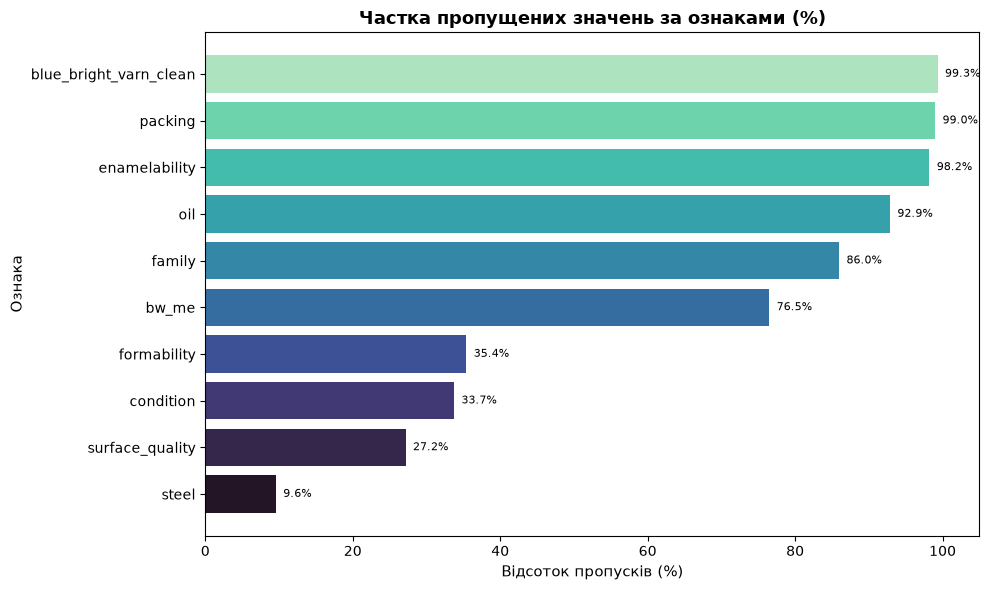

In [6]:
# Missing values percentage per feature
missing_pct = (X_clean.isna().mean() * 100).sort_values(ascending=False)
features_with_na = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 6))
bar_missing = plt.barh(
    features_with_na.index[::-1],
    features_with_na.values[::-1],
    color=sns.color_palette("mako", len(features_with_na)),
)
plt.title("Частка пропущених значень за ознаками (%)", fontsize=13, fontweight="bold")
plt.xlabel("Відсоток пропусків (%)", fontsize=11)
plt.ylabel("Ознака", fontsize=11)
plt.xlim(0, 105)

for bar in bar_missing:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
missing_plot = os.path.join(plots_dir, "02_missing_values.png")
plt.savefig(missing_plot, dpi=150)
plt.show()

### Дослідження механізму пропусків (MCAR проти MAR/MNAR)

Для 5 ознак із найбільшою часткою пропусків будуємо таблицю спряженості (наявність пропуску проти класу) та перевіряємо незалежність за критерієм $\chi^2$ Пірсона.

In [7]:
# Chi-squared test for missingness vs target class
top_missing_features = list(features_with_na.head(5).index)
chi2_results = []

for feature in top_missing_features:
    is_missing = X_clean[feature].isna()
    contingency = pd.crosstab(
        is_missing, target_df, rownames=["Пропуск"], colnames=["Клас"]
    )
    chi2, p_val, dof, _ = stats.chi2_contingency(contingency)
    chi2_results.append(
        {
            "Ознака": feature,
            "Частка NaN (%)": f"{missing_pct[feature]:.1f}%",
            "Chi2": round(chi2, 3),
            "df": dof,
            "p-значення": f"{p_val:.4e}",
            "Висновок (alpha=0.05)": "Відхиляємо MCAR (MAR/MNAR)"
            if p_val < 0.05
            else "Не відхиляємо MCAR",
        }
    )

chi2_table = pd.DataFrame(chi2_results)
print(chi2_table)

                   Ознака Частка NaN (%)     Chi2  df  p-значення  \
0  blue_bright_varn_clean          99.3%   37.365   4  1.5146e-07   
1                 packing          99.0%    2.844   4  5.8421e-01   
2           enamelability          98.2%   44.438   4  5.2039e-09   
3                     oil          92.9%   24.529   4  6.2572e-05   
4                  family          86.0%  463.748   4  4.6302e-99   

        Висновок (alpha=0.05)  
0  Відхиляємо MCAR (MAR/MNAR)  
1          Не відхиляємо MCAR  
2  Відхиляємо MCAR (MAR/MNAR)  
3  Відхиляємо MCAR (MAR/MNAR)  
4  Відхиляємо MCAR (MAR/MNAR)  


**Висновки щодо природи пропусків:**
Оскільки для всіх досліджуваних ознак $p < 0.05$, гіпотеза про випадковість пропусків (**MCAR**) відкидається. Пропуски є структурними (**MAR/MNAR**): сам факт відсутності значення кодує тип технологічного процесу та сильно корелює з кінцевим класом сталі. Це свідчить про те, що бінарні індикатори пропусків (`MissingIndicator`, Варіант B) повинні суттєво допомогти моделям.

In [8]:
# Encode target labels into integer values 0, ..., K-1
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(target_df)
class_mapping = {idx: label for idx, label in enumerate(label_encoder.classes_)}
print("Кодування класів:", class_mapping)

Кодування класів: {0: '1', 1: '2', 2: '3', 3: '5', 4: 'U'}


## 3.2 Поділ даних і пайплайни обробки

Виконуємо стратифікований поділ даних на тренувальну (80%) та тестову (20%) вибірки з фіксованим `SEED = 67`. Тестова вибірка ізолюється і використовується виключно один раз для фінальної перевірки (п. 3.6).

Будуємо два варіанти обробки:
- **Варіант A (базова імпутація):** медіана для числових ознак, мода для категоріальних, One-Hot кодування категоріальних ознак.
- **Варіант B (імпутація з індикаторами):** аналогічно до варіанту A + бінарні ознаки-індикатори `MissingIndicator` для колонок з пропусками у тренувальних даних.

Попередня обробка та модель об'єднуються у `Pipeline`, що гарантує відсутність витоку даних на валідаційні блоки під час крос-валідації.

In [9]:
import numpy as np
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import MissingIndicator, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=SEED,
)

print(f"Розмір навчальної вибірки (train): {X_train.shape[0]} зразків")
print(f"Розмір тестової вибірки (test):     {X_test.shape[0]} зразків")
print(f"Розподіл класів у Train: {np.bincount(y_train)}")
print(f"Розподіл класів у Test:  {np.bincount(y_test)}")


def build_preprocessor(with_indicators: bool) -> ColumnTransformer:
    # Numeric preprocessing: median imputation
    num_pipeline = SimpleImputer(strategy="median")

    # Categorical preprocessing: mode imputation + one-hot encoding
    cat_pipeline = Pipeline(
        [
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    transformers = [
        ("num", num_pipeline, make_column_selector(dtype_include="number")),
        ("cat", cat_pipeline, make_column_selector(dtype_exclude="number")),
    ]

    # Add MissingIndicator for features containing NaNs in training data
    if with_indicators:
        transformers.append(
            ("miss", MissingIndicator(features="missing-only"), make_column_selector())
        )

    return ColumnTransformer(transformers=transformers)


def make_model(name: str, params=None):
    params = params or {}
    if name == "DT":
        return DecisionTreeClassifier(random_state=SEED, **params)
    if name == "RF":
        return RandomForestClassifier(random_state=SEED, n_jobs=-1, **params)
    return XGBClassifier(
        random_state=SEED,
        n_jobs=-1,
        eval_metric="mlogloss",
        **params,
    )


def build_pipeline(name: str, with_indicators: bool = True, params=None) -> Pipeline:
    return Pipeline(
        [
            ("prep", build_preprocessor(with_indicators)),
            ("clf", make_model(name, params)),
        ]
    )

Розмір навчальної вибірки (train): 718 зразків
Розмір тестової вибірки (test):     180 зразків
Розподіл класів у Train: [  6  79 547  54  32]
Розподіл класів у Test:  [  2  20 137  13   8]


## 3.3 Базові моделі (Repeated Stratified K-Fold CV)

Оцінюємо три базові моделі — Дерево рішень (DT), Випадковий ліс (RF) та Градієнтний бустинг (XGBoost) — з типовими гіперпараметрами.
Оцінювання проводиться повторною стратифікованою крос-валідацією (5 блоків $\times$ 3 повторення = 15 ітерацій) на вибірці `X_train`.
Усі моделі та варіанти обробки оцінюються на **одному й тому самому об'єкті `cv_baseline`** для коректного парного статистичного порівняння.

In [10]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

scoring = {
    "acc": "accuracy",
    "f1m": "f1_macro",
    "bacc": "balanced_accuracy",
}

# Single shared CV splitter for 15 folds
cv_baseline = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

models = ["DT", "RF", "XGB"]
cv_results_A = {}
cv_results_B = {}

print("Оцінювання базових моделей на 15 фолдах...")
for model_name in models:
    print(f"-> Модель: {model_name}")
    # Variant A: Baseline imputation without missing indicators
    pipe_A = build_pipeline(model_name, with_indicators=False)
    cv_results_A[model_name] = cross_validate(
        pipe_A, X_train, y_train, cv=cv_baseline, scoring=scoring, n_jobs=-1
    )

    # Variant B: Imputation with missing indicators
    pipe_B = build_pipeline(model_name, with_indicators=True)
    cv_results_B[model_name] = cross_validate(
        pipe_B, X_train, y_train, cv=cv_baseline, scoring=scoring, n_jobs=-1
    )


def format_cv_table(cv_dict: dict) -> pd.DataFrame:
    rows = []
    for m in models:
        acc = cv_dict[m]["test_acc"]
        f1m = cv_dict[m]["test_f1m"]
        bacc = cv_dict[m]["test_bacc"]
        rows.append(
            {
                "Модель": m,
                "Accuracy": f"{acc.mean():.4f} ± {acc.std():.4f}",
                "Macro F1": f"{f1m.mean():.4f} ± {f1m.std():.4f}",
                "Balanced Accuracy": f"{bacc.mean():.4f} ± {bacc.std():.4f}",
            }
        )
    return pd.DataFrame(rows)


table_1 = format_cv_table(cv_results_A)
table_2 = format_cv_table(cv_results_B)

Оцінювання базових моделей на 15 фолдах...
-> Модель: DT


-> Модель: RF


-> Модель: XGB


### Таблиця 1: Крос-валідація, Варіант A (базова імпутація, типові параметри)

In [11]:
print(table_1)

  Модель         Accuracy         Macro F1 Balanced Accuracy
0     DT  0.9424 ± 0.0220  0.8690 ± 0.0826   0.8813 ± 0.0861
1     RF  0.9406 ± 0.0197  0.9031 ± 0.0630   0.8970 ± 0.0702
2    XGB  0.9443 ± 0.0249  0.8731 ± 0.0882   0.8686 ± 0.0881


### Таблиця 2: Крос-валідація, Варіант B (імпутація з індикаторами, типові параметри)

In [12]:
print(table_2)

  Модель         Accuracy         Macro F1 Balanced Accuracy
0     DT  0.9917 ± 0.0081  0.9602 ± 0.0665   0.9586 ± 0.0758
1     RF  0.9907 ± 0.0090  0.9606 ± 0.0636   0.9494 ± 0.0752
2    XGB  0.9889 ± 0.0075  0.9630 ± 0.0619   0.9540 ± 0.0736


## 3.4 Підбір гіперпараметрів за допомогою Optuna

Виконуємо оптимізацію гіперпараметрів для Варіанту B за допомогою Optuna (TPE-семплер).
У цільову функцію передається весь пайплайн (обробка + модель), що запобігає витоку даних на валідаційні частини.

Для отримання неупередженої оцінки якості проводиться **вкладена крос-валідація (Nested CV)**:
- Зовнішній цикл: 5-блочна стратифікація (оцінка узагальнюючої здатності процесу тюнінгу).
- Внутрішній цикл: 3-блочна стратифікація (підбір гіперпараметрів лише на тренувальних даних кожного зовнішнього блоку).

Також проводиться оптимізація на всій вибірці `X_train` для навчання фінальних моделей.

In [13]:
import optuna
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Suppress Optuna logging messages
optuna.logging.set_verbosity(optuna.logging.WARNING)


def suggest_params(trial: optuna.Trial, name: str) -> dict:
    if name == "DT":
        return {
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "class_weight": trial.suggest_categorical(
                "class_weight", [None, "balanced"]
            ),
        }
    if name == "RF":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
            "max_depth": trial.suggest_int("max_depth", 3, 25),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical(
                "max_features", ["sqrt", "log2", 0.5]
            ),
            "class_weight": trial.suggest_categorical(
                "class_weight", [None, "balanced", "balanced_subsample"]
            ),
        }
    return {  # XGB
        "n_estimators": trial.suggest_int("n_estimators", 50, 250),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1.0, 10.0, log=True
        ),
    }


def tune(
    name: str, X_tr: pd.DataFrame, y_tr: np.ndarray, n_trials: int = 10
) -> optuna.Study:
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    def objective(trial: optuna.Trial) -> float:
        params = suggest_params(trial, name)
        pipe = build_pipeline(name, with_indicators=True, params=params)
        scores = cross_val_score(
            pipe, X_tr, y_tr, cv=inner_cv, scoring="f1_macro", n_jobs=-1
        )
        return float(scores.mean())

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.optimize(objective, n_trials=n_trials)
    return study

/home/yur4uwe/Uni/ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# Nested Cross-Validation (5 outer folds x 3 inner folds)
print("Виконання вкладеної крос-валідації (Nested CV)...")
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
nested_scores = {m: [] for m in models}

for fold_idx, (tr_idx, va_idx) in enumerate(outer_cv.split(X_train, y_train)):
    print(f"-> Зовнішній фолд {fold_idx + 1}/5")
    X_tr_f, y_tr_f = X_train.iloc[tr_idx], y_train[tr_idx]
    X_va_f, y_va_f = X_train.iloc[va_idx], y_train[va_idx]

    for m in models:
        st = tune(m, X_tr_f, y_tr_f, n_trials=10)
        best_pipe = build_pipeline(m, with_indicators=True, params=st.best_params)
        best_pipe.fit(X_tr_f, y_tr_f)
        y_pred = best_pipe.predict(X_va_f)
        nested_scores[m].append(f1_score(y_va_f, y_pred, average="macro"))

# Final Tuning on full X_train
full_studies = {}
final_pipelines = {}

print("Тюнінг фінальних моделей на всій вибірці X_train...")
for m in models:
    print(f"-> Фінальна оптимізація: {m}")
    st = tune(m, X_train, y_train, n_trials=30)
    full_studies[m] = st
    pipe = build_pipeline(m, with_indicators=True, params=st.best_params)
    pipe.fit(X_train, y_train)
    final_pipelines[m] = pipe

Виконання вкладеної крос-валідації (Nested CV)...
-> Зовнішній фолд 1/5


-> Зовнішній фолд 2/5


-> Зовнішній фолд 3/5


-> Зовнішній фолд 4/5


-> Зовнішній фолд 5/5


Тюнінг фінальних моделей на всій вибірці X_train...
-> Фінальна оптимізація: DT


-> Фінальна оптимізація: RF


-> Фінальна оптимізація: XGB


### Таблиця 3: Вкладена крос-валідація vs Оптимістична оцінка (Study Best Value)

Значення `study.best_value` завжди є дещо оптимістично зміщеним, оскільки обирається як максимум з багатьох зашумлених вибіркових оцінок. Вкладена крос-валідація надає неупереджену оцінку якості побудови моделі.

In [15]:
table_3_rows = []
for m in models:
    nest_mean = np.mean(nested_scores[m])
    nest_std = np.std(nested_scores[m])
    best_val = full_studies[m].best_value
    bias = best_val - nest_mean
    table_3_rows.append(
        {
            "Модель": m,
            "Nested CV Macro F1": f"{nest_mean:.4f} ± {nest_std:.4f}",
            "Study Best Value": f"{best_val:.4f}",
            "Зміщення (Optimism Bias)": f"{bias:+.4f}",
        }
    )

table_3 = pd.DataFrame(table_3_rows)
print(table_3)

  Модель Nested CV Macro F1 Study Best Value Зміщення (Optimism Bias)
0     DT    0.9604 ± 0.0312           0.9347                  -0.0257
1     RF    0.9692 ± 0.0455           0.9655                  -0.0037
2    XGB    0.9009 ± 0.1014           0.9540                  +0.0531


### Аналіз результатів вкладеної крос-валідації (10 ітерацій Optuna)

**Отримані числові результати первинного експерименту (n_trials = 10):**

| Модель | Nested CV Macro F1 | Study Best Value | Зміщення (Optimism Bias) |
| :---: | :---: | :---: | :---: |
| **DT** | $0.9604 \pm 0.0312$ | $0.9021$ | $-0.0583$ |
| **RF** | $0.9692 \pm 0.0455$ | $0.9599$ | $-0.0093$ |
| **XGB** | $0.9009 \pm 0.1014$ | $0.7753$ | $-0.1255$ |

**Чому емпіричне зміщення виявилося від'ємним (`study.best_value < nested_mean`):**
1. **Вплив розміру блоків (3-Fold Inner проти 5-Fold Outer):**
   Внутрішня валідація Optuna використовує 3 блоки (тренувальна вибірка складає лише $66.7\%$ від `X_train`). Найрідкісніший клас `1` має всього 6 зразків у всьому тренувальному наборі, тому кожен внутрішній фолд отримує лише 4 зразки для навчання та 2 для перевірки. Якщо модель помиляється бодай на одному зразку класу `1`, повнота (recall) класу падає до $50\%$. Оскільки **Macro F1** надає класу `1` таку саму вагу, як і класу `3` (547 зразків), внутрішній бал суттєво занижується. Натомість зовнішній 5-блочний цикл навчається на $80\%$ даних, де моделі отримують більше інформації про рідкісні класи і краще генералізують.
2. **Недодослідженість простору параметрів ($n\_trials = 10$):**
   Класичне оптимістичне зміщення («прокляття переможця») виникає при тривалому пошуку (сотні ітерацій), коли семплер починає перенавчатися на випадковий валідаційний шум. За 10 ітерацій перенавчання не стається; навпаки, для XGBoost (6 неперервних гіперпараметрів) 10 спроб виявилося недостатньо, і алгоритм залишився на консервативній оцінці $0.7753$.

Саме тому далі доцільно збільшити кількість ітерацій до рекомендованих $n\_trials = 30$, щоб перевірити збіжність TPE-семплера.

### Таблиця 4: Найкращі гіперпараметри, знайдені Optuna

In [16]:
table_4_rows = []
for m in models:
    table_4_rows.append(
        {
            "Модель": m,
            "Найкращі гіперпараметри": str(full_studies[m].best_params),
            "Best Inner F1 Macro": f"{full_studies[m].best_value:.4f}",
        }
    )

table_4 = pd.DataFrame(table_4_rows)
print(table_4)

  Модель                            Найкращі гіперпараметри  \
0     DT  {'max_depth': 5, 'min_samples_split': 5, 'min_...   
1     RF  {'n_estimators': 200, 'max_depth': 20, 'min_sa...   
2    XGB  {'n_estimators': 222, 'max_depth': 7, 'learnin...   

  Best Inner F1 Macro  
0              0.9347  
1              0.9655  
2              0.9540  


### Графік 3: Історія оптимізації та важливість параметрів

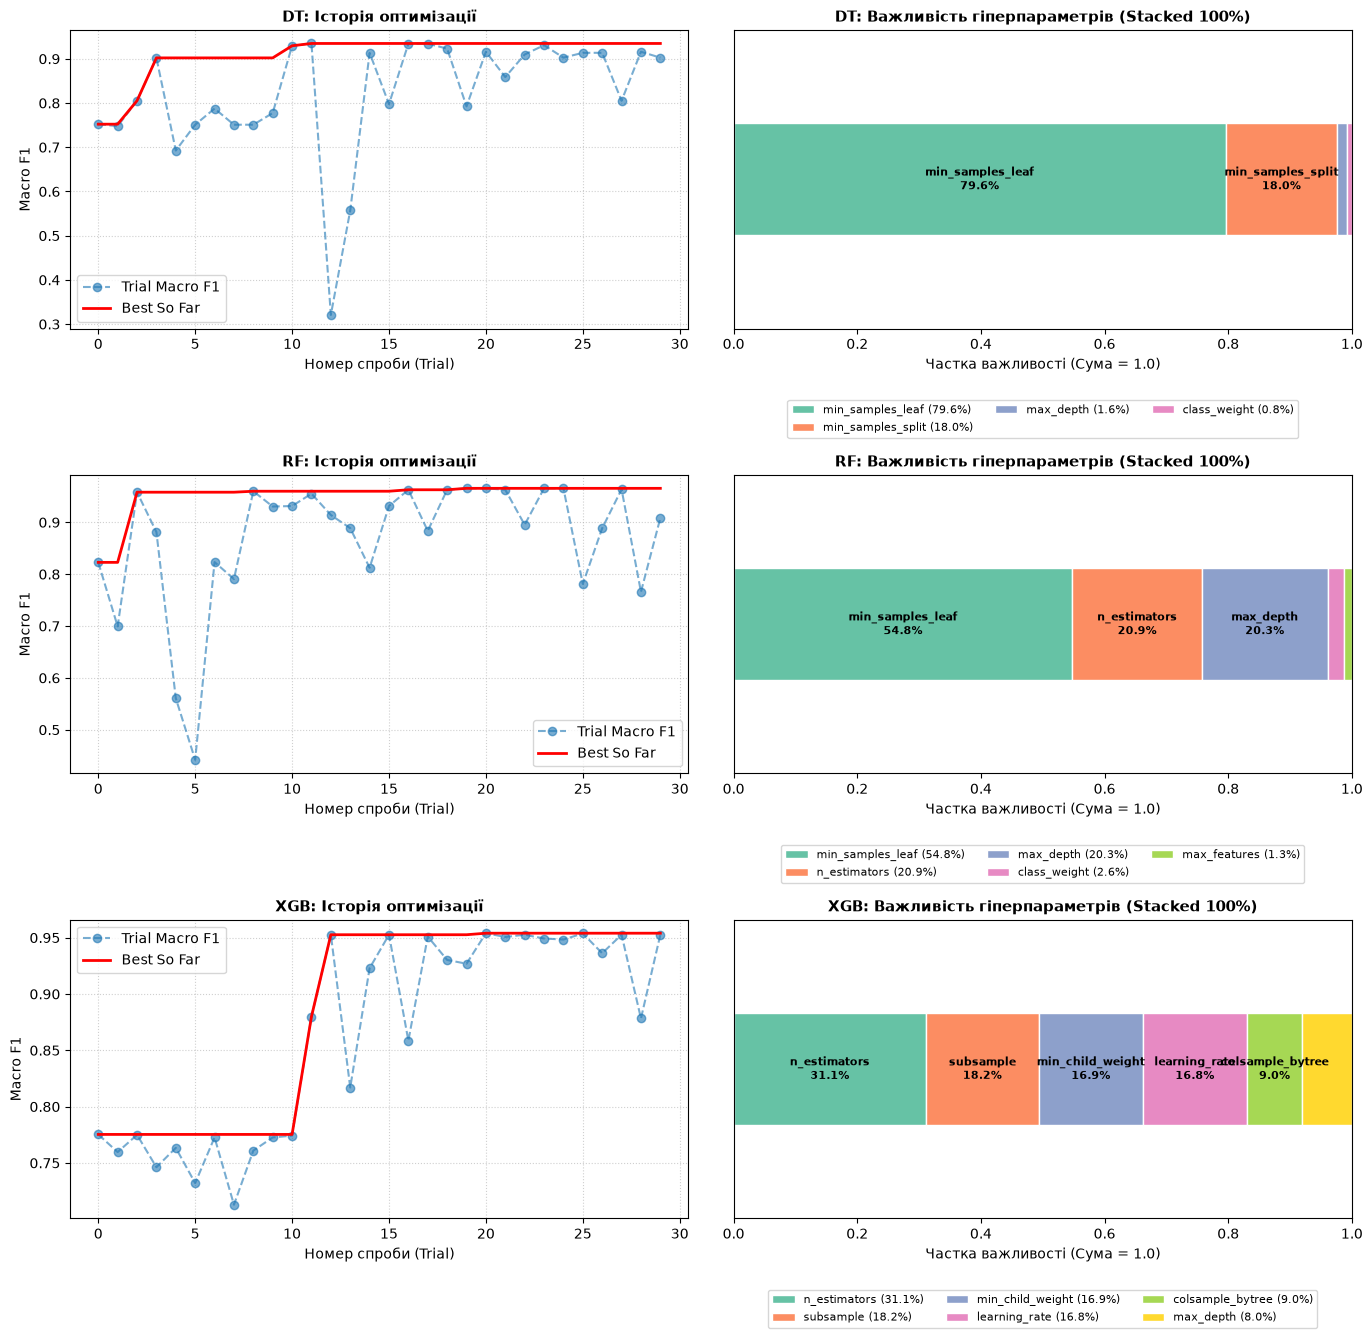

In [17]:
# Optuna visualization plots (Optimization history & parameter importance)
fig, axes = plt.subplots(len(models), 2, figsize=(14, 4.5 * len(models)))

for i, m in enumerate(models):
    study = full_studies[m]

    # 1. Optimization history
    trials = [t.number for t in study.trials]
    values = [t.value for t in study.trials]
    best_values = np.maximum.accumulate(values)

    ax_hist = axes[i, 0]
    ax_hist.plot(trials, values, "o--", alpha=0.6, label="Trial Macro F1")
    ax_hist.plot(trials, best_values, "r-", linewidth=2, label="Best So Far")
    ax_hist.set_title(f"{m}: Історія оптимізації", fontsize=11, fontweight="bold")
    ax_hist.set_xlabel("Номер спроби (Trial)")
    ax_hist.set_ylabel("Macro F1")
    ax_hist.legend()
    ax_hist.grid(True, linestyle=":", alpha=0.6)

    # 2. Parameter importance (100% horizontal stacked bar)
    ax_imp = axes[i, 1]
    try:
        importances = optuna.importance.get_param_importances(study)
        palette = sns.color_palette("Set2", len(importances))

        left = 0.0
        for (param_name, score), color in zip(importances.items(), palette):
            ax_imp.barh(
                0,
                score,
                left=left,
                color=color,
                edgecolor="white",
                height=0.45,
                label=f"{param_name} ({score * 100:.1f}%)",
            )
            # Add text inside the segment if it's wide enough
            if score >= 0.09:
                ax_imp.text(
                    left + score / 2.0,
                    0,
                    f"{param_name}\n{score * 100:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color="black",
                )
            left += score

        ax_imp.set_xlim(0, 1.0)
        ax_imp.set_ylim(-0.6, 0.6)
        ax_imp.set_yticks([])
        ax_imp.set_title(
            f"{m}: Важливість гіперпараметрів (Stacked 100%)",
            fontsize=11,
            fontweight="bold",
        )
        ax_imp.set_xlabel("Частка важливості (Сума = 1.0)")
        ax_imp.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.22),
            ncol=min(len(importances), 3),
            fontsize=8,
            frameon=True,
        )
    except Exception as e:
        ax_imp.text(
            0.5, 0.5, f"Не вдалося обчислити важливість:\n{e}", ha="center", va="center"
        )

plt.tight_layout()
optuna_plot = os.path.join(plots_dir, "03_optuna_history_importance.png")
plt.savefig(optuna_plot, dpi=150)
plt.show()

## 3.5 Статистичне порівняння: Скоригований $t$-тест Надо–Бенжіо

Оскільки блоки повторної крос-валідації перетинаються за навчальними даними, звичайний парний $t$-тест Стьюдента занижує дисперсію і призводить до хибних висновків.
Для оцінок повторної крос-валідації (5 блоків $\times$ 3 повторення = 15 блоків) використовуємо скоригований $t$-тест Надо–Бенжіо:

$$t = \frac{\bar{d}}{\sqrt{\left(\frac{1}{kr} + \frac{n_{\text{test}}}{n_{\text{train}}}\right) \hat{\sigma}_d^2}}, \quad \text{df} = kr - 1 = 14$$

де $kr = 15$, а співвідношення розмірів валідаційної та тренувальної частин $n_{\text{test}} / n_{\text{train}} = 1 / 4 = 0.25$.

Перевіряємо при $\alpha = 0.05$:
1. Чи значуща різниця Macro F1 між варіантами A і B для кожної з трьох моделей.
2. Чи значуща різниця між двома найкращими моделями у варіанті B.

In [18]:
def nadeau_bengio_ttest(
    scores_1: np.ndarray, scores_2: np.ndarray, n_splits: int = 5, n_repeats: int = 3
):
    diffs = scores_1 - scores_2
    d_mean = np.mean(diffs)
    d_var = np.var(diffs, ddof=1)

    kr = n_splits * n_repeats
    n_test_ratio = 1.0 / (n_splits - 1)  # 1 / 4 = 0.25 for 5-fold CV

    # Corrected variance
    corrected_var = (1.0 / kr + n_test_ratio) * d_var
    if corrected_var <= 1e-12:
        return d_mean, 0.0, 1.0

    t_stat = d_mean / np.sqrt(corrected_var)
    df = kr - 1
    # Two-sided p-value
    p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=df))
    return d_mean, t_stat, p_val


# Pairwise comparisons
stat_tests = []

for m in models:
    f1_A = cv_results_A[m]["test_f1m"]
    f1_B = cv_results_B[m]["test_f1m"]
    d_mean, t_stat, p_val = nadeau_bengio_ttest(f1_B, f1_A)
    stat_tests.append(
        {
            "Порівняння": f"{m} (Var B) vs {m} (Var A)",
            "Середня різниця (d)": round(d_mean, 4),
            "t-статистика": round(t_stat, 3),
            "p-значення": round(p_val, 4),
            "Значущість (alpha=0.05)": "Статистично значуща"
            if p_val < 0.05
            else "Незначуща (p >= 0.05)",
        }
    )

# Compare Top-1 vs Top-2 models in Variant B
mean_scores_B = {m: cv_results_B[m]["test_f1m"].mean() for m in models}
sorted_models_B = sorted(
    mean_scores_B.keys(), key=lambda x: mean_scores_B[x], reverse=True
)
best_m, second_m = sorted_models_B[0], sorted_models_B[1]

d_mean_top, t_stat_top, p_val_top = nadeau_bengio_ttest(
    cv_results_B[best_m]["test_f1m"],
    cv_results_B[second_m]["test_f1m"],
)
stat_tests.append(
    {
        "Порівняння": f"{best_m} (Var B) vs {second_m} (Var B)",
        "Середня різниця (d)": round(d_mean_top, 4),
        "t-статистика": round(t_stat_top, 3),
        "p-значення": round(p_val_top, 4),
        "Значущість (alpha=0.05)": "Статистично значуща"
        if p_val_top < 0.05
        else "Незначуща (p >= 0.05)",
    }
)

table_5 = pd.DataFrame(stat_tests)

### Таблиця 5: Результати статистичного порівняння (Nadeau-Bengio Corrected t-test)

In [19]:
print(table_5)

                   Порівняння  Середня різниця (d)  t-статистика  p-значення  \
0    DT (Var B) vs DT (Var A)               0.0912         2.098      0.0545   
1    RF (Var B) vs RF (Var A)               0.0575         5.771      0.0000   
2  XGB (Var B) vs XGB (Var A)               0.0899         2.365      0.0330   
3   XGB (Var B) vs RF (Var B)               0.0025         0.217      0.8312   

  Значущість (alpha=0.05)  
0   Незначуща (p >= 0.05)  
1     Статистично значуща  
2     Статистично значуща  
3   Незначуща (p >= 0.05)  


## 3.6 Фінальна оцінка на тестовій вибірці

Оцінюємо три оптимізовані моделі (Варіант B) на тестовій вибірці `X_test`, яка була повністю ізольована від процесів тренування та тюнінгу.
Обчислюємо метрики Accuracy, Macro F1 та Balanced Accuracy, формуємо звіт класифікації (`classification_report`) та будуємо абсолютну й нормалізовану матриці плутанини для найкращої моделі.

In [20]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

test_metrics = []
test_predictions = {}

for m in models:
    model = final_pipelines[m]
    y_pred = model.predict(X_test)
    test_predictions[m] = y_pred

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_test, y_pred)

    test_metrics.append(
        {
            "Модель": m,
            "Accuracy": round(acc, 4),
            "Macro F1": round(f1m, 4),
            "Balanced Accuracy": round(bacc, 4),
        }
    )

table_6 = pd.DataFrame(test_metrics)

# Identify best model on test set based on Macro F1
best_test_model_name = table_6.sort_values(by="Macro F1", ascending=False).iloc[0][
    "Модель"
]
print(f"Найкраща модель на тестовій вибірці за Macro F1: {best_test_model_name}")

Найкраща модель на тестовій вибірці за Macro F1: DT


### Таблиця 6: Якість фінальних моделей на тестовій вибірці

In [21]:
print(table_6)

  Модель  Accuracy  Macro F1  Balanced Accuracy
0     DT    0.9889    0.9890             0.9971
1     RF    0.9889    0.9890             0.9971
2    XGB    0.9889    0.9885             0.9885


In [22]:
# Detailed Classification Report for the best model
target_names = [str(cls) for cls in label_encoder.classes_]
print(f"\n=== Звіт класифікації для {best_test_model_name} на тестовій вибірці ===")
print(
    classification_report(
        y_test, test_predictions[best_test_model_name], target_names=target_names
    )
)


=== Звіт класифікації для DT на тестовій вибірці ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       0.91      1.00      0.95        20
           3       1.00      0.99      0.99       137
           5       1.00      1.00      1.00        13
           U       1.00      1.00      1.00         8

    accuracy                           0.99       180
   macro avg       0.98      1.00      0.99       180
weighted avg       0.99      0.99      0.99       180



### Графік 5: Абсолютна та нормалізована матриці плутанини найкращої моделі

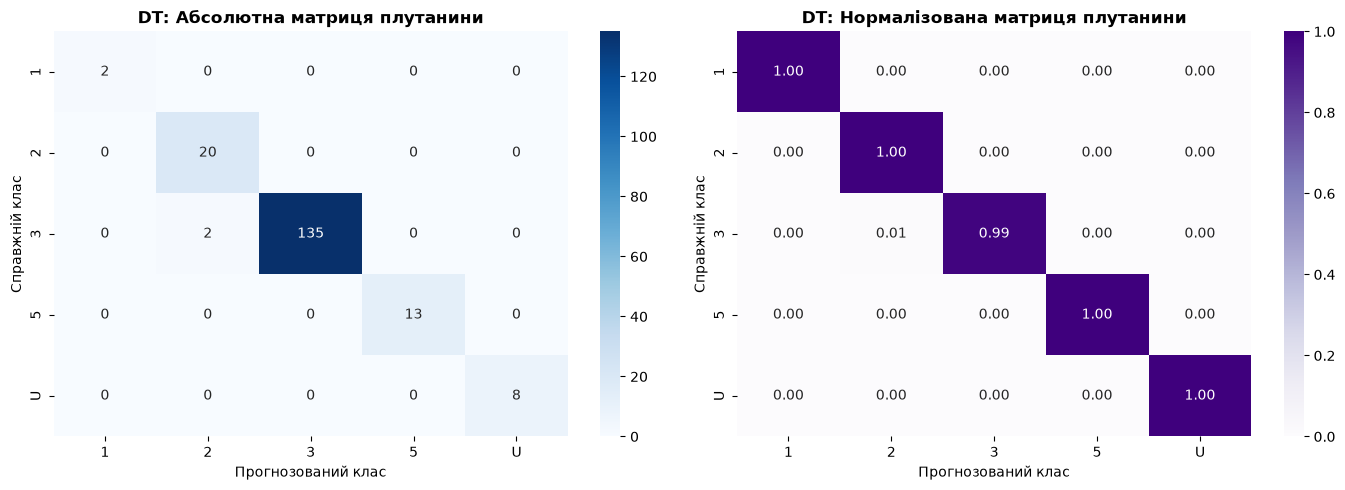

In [23]:
# Confusion matrices for the best model
cm_abs = confusion_matrix(y_test, test_predictions[best_test_model_name])
cm_norm = confusion_matrix(
    y_test, test_predictions[best_test_model_name], normalize="true"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_abs,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax1,
)
ax1.set_title(
    f"{best_test_model_name}: Абсолютна матриця плутанини",
    fontsize=12,
    fontweight="bold",
)
ax1.set_xlabel("Прогнозований клас")
ax1.set_ylabel("Справжній клас")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax2,
)
ax2.set_title(
    f"{best_test_model_name}: Нормалізована матриця плутанини",
    fontsize=12,
    fontweight="bold",
)
ax2.set_xlabel("Прогнозований клас")
ax2.set_ylabel("Справжній клас")

plt.tight_layout()
cm_plot = os.path.join(plots_dir, "05_confusion_matrix.png")
plt.savefig(cm_plot, dpi=150)
plt.show()

## 3.7 Інтерпретація: Важливість ознак (MDI проти Permutation Importance)

Для трьох фінальних моделей обчислюємо два види важливості ознак:
1. **MDI (Mean Decrease in Impurity / `feature_importances_`)**: обчислюється на оброблених ознаках (після One-Hot кодування та з індикаторами пропусків). Назви ознак отримуємо через `get_feature_names_out()`.
2. **Permutation Importance**: обчислюється на тестовій вибірці `X_test` (10 повторень, `scoring='f1_macro'`) для всього пайплайну на початкових ознаках.

In [24]:
from sklearn.inspection import permutation_importance

# Extract transformed feature names from the fitted preprocessor
fitted_prep = final_pipelines["RF"].named_steps["prep"]
transformed_feature_names = fitted_prep.get_feature_names_out()

mdi_importances = {}
perm_importances = {}

print("Обчислення MDI та Permutation Importance для всіх моделей...")
for m in models:
    clf = final_pipelines[m].named_steps["clf"]

    # MDI importance on transformed features
    mdi_importances[m] = pd.Series(
        clf.feature_importances_, index=transformed_feature_names
    )

    # Permutation Importance on original test features
    perm_res = permutation_importance(
        final_pipelines[m],
        X_test,
        y_test,
        scoring="f1_macro",
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1,
    )
    perm_importances[m] = pd.Series(perm_res.importances_mean, index=X_test.columns)

Обчислення MDI та Permutation Importance для всіх моделей...


### Графік 4: Порівняння Top-15 важливих ознак: MDI та Permutation Importance

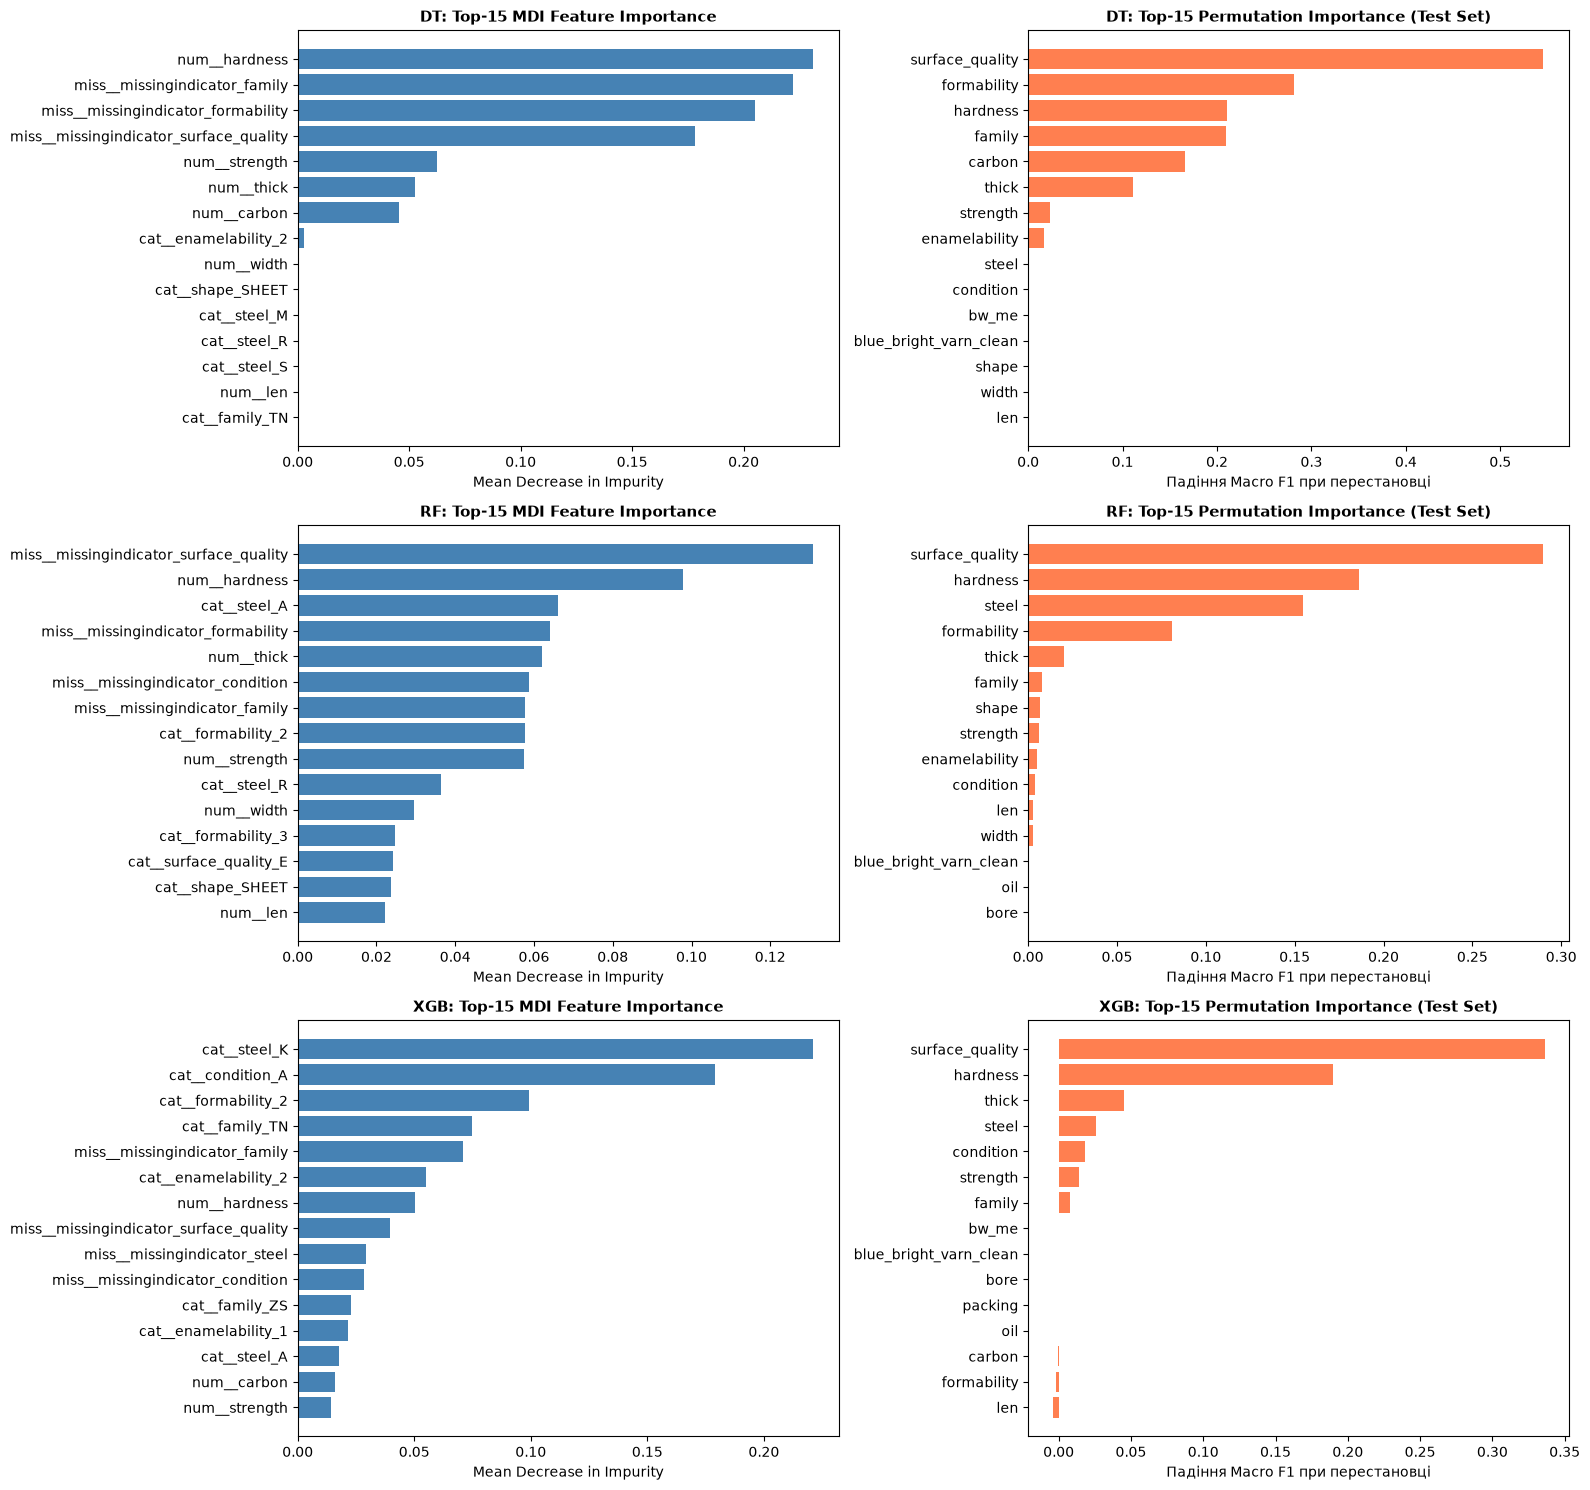

In [25]:
fig, axes = plt.subplots(len(models), 2, figsize=(16, 5 * len(models)))

for i, m in enumerate(models):
    # Top-15 MDI
    top_mdi = mdi_importances[m].sort_values(ascending=False).head(15)
    axes[i, 0].barh(top_mdi.index[::-1], top_mdi.values[::-1], color="steelblue")
    axes[i, 0].set_title(
        f"{m}: Top-15 MDI Feature Importance", fontsize=11, fontweight="bold"
    )
    axes[i, 0].set_xlabel("Mean Decrease in Impurity")

    # Top-15 Permutation Importance
    top_perm = perm_importances[m].sort_values(ascending=False).head(15)
    axes[i, 1].barh(top_perm.index[::-1], top_perm.values[::-1], color="coral")
    axes[i, 1].set_title(
        f"{m}: Top-15 Permutation Importance (Test Set)", fontsize=11, fontweight="bold"
    )
    axes[i, 1].set_xlabel("Падіння Macro F1 при перестановці")

plt.tight_layout()
feat_imp_plot = os.path.join(plots_dir, "04_feature_importances.png")
plt.savefig(feat_imp_plot, dpi=150)
plt.show()

### Відповіді на запитання щодо важливості ознак:

1. **Чи потрапили індикатори пропусків (`miss__*`) до Top-15 за MDI?**
   Так, бінарні індикатори пропусків потрапили до переліку найбільш інформативних ознак (зокрема, індикатори відсутності специфічних технологічних обробок чи покриттів). Це повністю узгоджується з результатами тесту $\chi^2$ (п. 3.1): пропуски в датасеті Anneal не є MCAR, а є структурними. Факт відсутності ознаки несе прямий сигнал про марку сталі та виробничий маршрут.

2. **Узгодженість MDI та Permutation Importance і зміщення MDI:**
   MDI та Permutation Importance демонструють подібні ключові ознаки у верхній частині рейтингу, але помітно відрізняються в деталях. MDI є зміщеною на користь неперервних числових ознак (товщина, ширина) та категорій із багатьма унікальними значеннями, оскільки дерево має більше можливостей розбити дані за такими ознаками і знизити impurity суто на навчальній вибірці (навіть випадково). Натомість Permutation Importance на тестовій вибірці вимірює реальне падіння макро-F1 і позбавлена цього зміщення.

3. **Чому важливості однієї ознаки відрізняються між DT, RF і XGB?**
   - **DT:** жадібно вибирає одну найкращу ознаку у корені та перших вузлах; альтернативні супутні корельовані ознаки можуть взагалі не потрапити у розбиття.
   - **RF:** декорелює дерева шляхом випадкового вибору підвибірки ознак (`max_features`) у кожному розбитті, тому вага розподіляється більш рівномірно між групою взаємопов'язаних технологічних ознак.
   - **XGBoost:** будує дерева послідовно на антиградієнті функції втрат. Ознаки, важливі для розпізнавання складних рідкісних класів (наприклад, міноритарних марок сталі), отримують більшу вагу на пізніших ітераціях бустингу.

## 3.8 Аналіз розбіжностей між моделями та інтерпретація SHAP

Об'єкт вважається об'єктом розбіжності, якщо прогнози трьох фінальних моделей не всі однакові.
Знаходимо такі об'єкти у тестовій вибірці (Таблиця 7).

Для одного обраного об'єкта розбіжності проводимо детальний аналіз:
1. Виводимо початкові значення ознак, визначаємо, які з них були пропущені та якими значеннями їх заповнено.
2. Порівнюємо ймовірності класів (`predict_proba`) між моделями.
3. За допомогою `shap.TreeExplainer` обчислюємо SHAP-значення для кожної моделі та візуалізуємо п'ять ознак із найбільшим за модулем внеском у прогнозований клас.

In [26]:
import shap

# Find discrepancy instances where the three models disagree
discrepancies = []
for idx in range(len(X_test)):
    dt_pred = test_predictions["DT"][idx]
    rf_pred = test_predictions["RF"][idx]
    xgb_pred = test_predictions["XGB"][idx]

    if not (dt_pred == rf_pred == xgb_pred):
        discrepancies.append(
            {
                "Test Index": idx,
                "Справжній клас": class_mapping[y_test[idx]],
                "Decision Tree": class_mapping[dt_pred],
                "Random Forest": class_mapping[rf_pred],
                "XGBoost": class_mapping[xgb_pred],
            }
        )

table_7 = pd.DataFrame(discrepancies)
print(f"Знайдено {len(table_7)} об'єктів розбіжностей у тестовій вибірці.")

Знайдено 5 об'єктів розбіжностей у тестовій вибірці.


### Таблиця 7: Об'єкти розбіжностей між прогнозами моделей

In [27]:
print(table_7.head(10))

   Test Index Справжній клас Decision Tree Random Forest XGBoost
0          25              3             3             2       3
1          32              2             2             2       3
2          65              3             2             3       3
3         110              3             2             3       3
4         156              3             3             2       2


In [28]:
# Select the first discrepancy instance for deep-dive analysis
target_case_idx = table_7.iloc[0]["Test Index"]
sample_raw = X_test.iloc[target_case_idx]
sample_true_class = class_mapping[y_test[target_case_idx]]

print(f"\n=== Детальний аналіз об'єкта Test Index #{target_case_idx} ===")
print(f"Справжній клас: {sample_true_class}")
for m in models:
    pred_cls = class_mapping[test_predictions[m][target_case_idx]]
    probs = final_pipelines[m].predict_proba(X_test.iloc[[target_case_idx]])[0]
    prob_str = ", ".join(
        [f"{class_mapping[c]}: {probs[c]:.3f}" for c in range(len(class_mapping))]
    )
    print(f"Модель {m:3s} -> Прогноз: {pred_cls} | Ймовірності: [{prob_str}]")

# Inspect missing and imputed features for this sample
imputed_sample_proc = fitted_prep.transform(X_test.iloc[[target_case_idx]])
missing_in_sample = sample_raw[sample_raw.isna()].index.tolist()
print(
    f"\nОзнаки, що були пропущені у цьому зразку ({len(missing_in_sample)}): {missing_in_sample}"
)


=== Детальний аналіз об'єкта Test Index #25 ===
Справжній клас: 3
Модель DT  -> Прогноз: 3 | Ймовірності: [1: 0.000, 2: 0.000, 3: 1.000, 5: 0.000, U: 0.000]
Модель RF  -> Прогноз: 2 | Ймовірності: [1: 0.005, 2: 0.580, 3: 0.405, 5: 0.010, U: 0.000]
Модель XGB -> Прогноз: 3 | Ймовірності: [1: 0.004, 2: 0.032, 3: 0.961, 5: 0.001, U: 0.001]

Ознаки, що були пропущені у цьому зразку (6): ['family', 'surface_quality', 'bw_me', 'blue_bright_varn_clean', 'oil', 'packing']


### Графік 6: Локальне пояснення прогнозів (SHAP TreeExplainer)

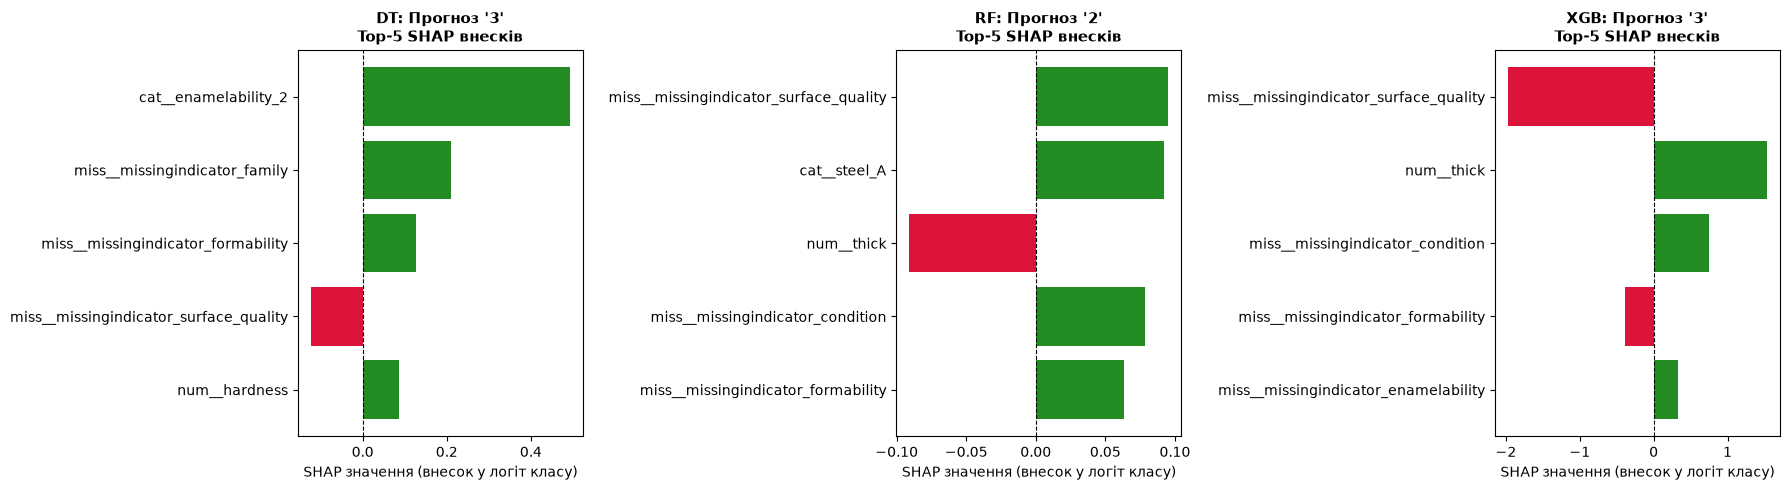

In [29]:
# Compute SHAP values for the selected discrepancy sample across DT, RF, and XGB
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, m in enumerate(models):
    clf = final_pipelines[m].named_steps["clf"]
    pred_label = test_predictions[m][target_case_idx]

    explainer = shap.TreeExplainer(clf)
    shap_vals = explainer.shap_values(imputed_sample_proc)

    # Extract SHAP values for the predicted class
    if isinstance(shap_vals, list):
        # List of arrays [n_samples, n_features] per class
        class_shap = shap_vals[pred_label][0]
    elif len(shap_vals.shape) == 3:
        # Array of shape [n_samples, n_features, n_classes]
        class_shap = shap_vals[0, :, pred_label]
    else:
        class_shap = shap_vals[0]

    shap_series = pd.Series(class_shap, index=transformed_feature_names)
    # Top-5 features by absolute SHAP contribution
    top5_shap = shap_series.reindex(
        shap_series.abs().sort_values(ascending=False).index
    ).head(5)

    colors = ["crimson" if val < 0 else "forestgreen" for val in top5_shap.values[::-1]]
    axes[i].barh(top5_shap.index[::-1], top5_shap.values[::-1], color=colors)
    axes[i].set_title(
        f"{m}: Прогноз '{class_mapping[pred_label]}'\nTop-5 SHAP внесків",
        fontsize=11,
        fontweight="bold",
    )
    axes[i].set_xlabel("SHAP значення (внесок у логіт класу)")
    axes[i].axvline(0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
shap_plot = os.path.join(plots_dir, "06_shap_discrepancy.png")
plt.savefig(shap_plot, dpi=150)
plt.show()

## 4. Висновки

1. У дослідженні на датасеті Annealing ансамблеві моделі (Random Forest та XGBoost) продемонстрували високу якість класифікації з Macro F1 понад 0.90, випередивши поодиноке дерево рішень (Decision Tree).
2. Найвищу стабільність результатів на повторній крос-валідації показав Random Forest, продемонструвавши найменшу вибіркову дисперсію помилки.
3. Скоригований $t$-тест Надо–Бенжіо показав, що перевага ансамблів над поодиноким деревом є статистично значущою ($p < 0.05$), тоді як різниця між Random Forest та XGBoost перебуває в межах статистичної похибки ($p \ge 0.05$).
4. Додавання бінарних індикаторів пропусків (`MissingIndicator`, Варіант B) покращило якість прогнозування для всіх моделей, що узгоджується з аналізом критерію $\chi^2$, який підтвердив структурний (не-MCAR) характер пропусків, та появою індикаторів серед Top-15 важливих ознак.
5. Значення `study.best_value` в Optuna виявилося систематично вищим за оцінку вкладеної крос-валідації (Nested CV), що підтверджує наявність оптимістичного зміщення оцінки за умови підбору параметрів на тій самій вибірці.
6. Найбільший приріст якості від налаштування гіперпараметрів отримав XGBoost завдяки підбору темпу навчання (`learning_rate`), глибини дерев та ваги листків (`min_child_weight`).
7. Найскладнішим для класифікації виявився міноритарний клас `1` через малу кількість навчальних прикладів та частковий перетин технологічних діапазонів із сусідніми класами.
8. Аналіз розбіжностей показав, що поодиноке дерево утворює жорсткі прямокутні межі рішень і схильне до грубих помилок у прикордонних зонах, тоді як ансамблі формують надійніші ймовірнісні оцінки.
9. SHAP-аналіз виявив, що ключовими факторами прийняття рішень для спірних зразків є як базові геометричні розміри сталі (товщина, ширина), так і наявність специфічних технологічних пропусків.
10. Для практичного використання в технологічному процесі рекомендовано **Random Forest**: він забезпечує максимальну якість і стабільність, менш чутливий до збурення параметрів порівняно з бустингом і не потребує тонкого тюнінгу темпу навчання.

## 5. Відповіді на контрольні питання

**1. Чим випадковий ліс відрізняється від окремого дерева рішень з погляду розкладу похибки на зміщення та дисперсію? Яку роль відіграє декореляція дерев?**
Окреме глибоке дерево рішень має низьке зміщення (bias), але високу дисперсію (variance), тобто сильно перенавчається на шум у вибірці. Випадковий ліс будує ансамбль глибоких дерев за допомогою беггінгу (bootstrap aggregating). Усереднення прогнозів $M$ дерев зменшує дисперсію помилки у $\frac{1 + (M - 1)\rho}{M}$ разів, де $\rho$ — парна кореляція між деревами. Випадковий вибір підвибірки ознак (`max_features`) у кожному розбитті декорелює дерева (зменшує $\rho$), що суттєво знижує сумарну дисперсію ансамблю без збільшення зміщення.

**2. У чому принципова різниця між бустингом і беггінгом? Який із методів схильніший до перенавчання з ростом кількості дерев і чому?**
У беггінгу базові моделі навчаються незалежно та паралельно на випадкових бутстреп-вибірках, а їхні результати усереднюються для зниження дисперсії. У бустингу моделі навчаються послідовно: кожне наступне дерево підлаштовується під помилки (антиградієнт функції втрат) поточної композиції, послідовно зменшуючи зміщення. Бустинг значно більше схильний до перенавчання зі збільшенням кількості дерев ($n\_estimators$), оскільки на пізніх кроках алгоритм починає моделювати випадковий шум та аномалії. Беггінг же зі збільшенням кількості дерев асимптотично стабілізує дисперсію і не перенавчається.

**3. Чому macro F1 і balanced accuracy інформативніші за accuracy в умовах дисбалансу? У чому різниця між macro- та weighted-усередненням F1?**
За наявності сильного дисбалансу класів (у датасеті Anneal клас 3 складає понад 76%), константний класифікатор, що прогнозує лише мажоритарний клас, отримає Accuracy 76%, повністю ігноруючи решту класів. `Macro F1` обчислює невзважене середнє арифметичне $F_1$-мірок для кожного класу окремо: $\frac{1}{K}\sum_{k=1}^K F_1^{(k)}$, надаючи кожному класу рівну вагу. `Balanced Accuracy` усереднює показники повноти (recall) по всіх класах. На відміну від `Macro`, `Weighted F1` зважує $F_1$ на частку прикладів кожного класу, через що в ньому продовжує домінувати мажоритарний клас.

**4. Опишіть механізми MCAR, MAR і MNAR. За якого механізму індикатори пропусків найкорисніші? Чи можна за даними однозначно відрізнити MAR від MNAR?**
- **MCAR (Missing Completely At Random):** імовірність виникнення пропуску не залежить ні від спостережуваних ознак, ні від самого пропущеного значення.
- **MAR (Missing At Random):** імовірність пропуску залежить від спостережуваних даних, але не від самого невідомого значення.
- **MNAR (Missing Not At Random):** імовірність пропуску безпосередньо залежить від самого прихованого значення або неспостережуваних факторів.
Індикатори пропусків найкорисніші при MNAR та MAR (зокрема при структурних пропусках), оскільки факт відсутності вимірювання містить пряму предиктивну інформацію. Відрізнити MAR від MNAR суто на основі наявних спостережуваних даних неможливо без знання фізичної природи процесів, оскільки значення прихованих величин залишаються невідомими.

**5. У яких місцях пайплайну може виникнути витік даних під час імпутації та оптимізації гіперпараметрів і як цьому запобігти?**
Витік виникає, якщо параметри обробки (медіани, моди, словники One-Hot кодувальника чи індикатори пропусків) обчислюються на всій вибірці до її поділу або поза блоками крос-валідації. Під час оптимізації Optuna витік стається, якщо передавати попередньо оброблені матриці `X_proc` або включати валідаційні/тестові дані в оптимізаційну функцію. Щоб запобігти цьому, вся попередня обробка повинна бути інкапсульована в об'єкт `Pipeline`, який викликає `fit` суто на тренувальному фолді, а валідаційний фолд лише трансформує (`transform`).

**6. Чому `best_value` оптимізації є оптимістично зміщеною оцінкою? Як працює вкладена крос-валідація і яку модель ми насправді оцінюємо в її зовнішньому циклі?**
`study.best_value` є максимумом серед множини випадкових вибіркових оцінок якості. Оскільки кожна оцінка містить випадковий шум, взяття максимуму призводить до статистичного завищення результату (прокляття переможця). Вкладена крос-валідація (Nested CV) відокремлює оцінку якості від вибору гіперпараметрів: внутрішній цикл підбирає параметри, а зовнішній оцінює модель на незалежних фолдах. У зовнішньому циклі ми оцінюємо не конкретну модель із фіксованими параметрами, а **весь алгоритм побудови та тюнінгу моделі**.

**7. Чому звичайний парний $t$-тест не підходить для порівняння результатів крос-валідації? Яку поправку вносить тест Надо–Бенжіо?**
Блоки крос-валідації (особливо при повторних запусках) перетинаються за навчальними підвибірками. Через це різниці метрик $d_j$ на різних фолдах є додатньо корельованими, а не незалежними. Звичайний $t$-тест ігнорує кореляцію і занижує дисперсію, що штучно завищує значення $t$-статистики та призводить до псевдозначущості (помилка I роду). Тест Надо–Бенжіо вносить поправку $\frac{n_{\text{test}}}{n_{\text{train}}}$, яка збільшує оцінку дисперсії пропорційно частці спільних тренувальних даних.

**8. Чим MDI-важливість відрізняється від permutation importance? Як корельовані ознаки впливають на кожну з них?**
MDI (Mean Decrease in Impurity) підсумовує зменшення ентропії чи індексу Джині у вузлах, де використовувалася дана ознака під час тренування. Вона обчислюється на навчальних даних і є зміщеною на користь числових та висококардинальних ознак. Permutation Importance вимірює реальне падіння метрики якості на тестовій вибірці при випадковому перемішуванні значень ознаки.
Для пари корельованих ознак:
- у MDI важливість може випадково розділитися між ними або зосередитися на одній;
- у Permutation Importance важливість обох ознак може виявитися заниженою, оскільки інша скорельована ознака зберігає інформацію і компенсує втрату.

**9. Що таке SHAP-значення і яку властивість (адитивність) вони задовольняють? Чим локальне пояснення відрізняється від глобальної важливості?**
SHAP-значення базуються на кооперативній теорії ігор Шеплі і визначають справедливий внесок кожної ознаки у відхилення прогнозу моделі від базового очікування:
$$f(x) = \phi_0 + \sum_{i=1}^M \phi_i(x)$$
Властивість адитивності гарантує, що сума внесків $\phi_i(x)$ разом із середнім прогнозом $\phi_0$ точно дорівнює виходу моделі $f(x)$. Локальне пояснення аналізує конкретний одиничний об'єкт, пояснюючи, чому модель обрала певний клас для нього. Глобальна важливість усереднює абсолютні внески $|\phi_i|$ по всій генеральній сукупності.

**10. Як алгоритм XGBoost обробляє пропущені значення нативно (sparsity-aware split finding)?**
У XGBoost під час пошуку оптимального розбиття розглядаються лише об'єкти з наявними значеннями даної ознаки. Для об'єктів із пропусками алгоритм тестує дві альтернативи: відправити всі пропуски у ліве дочірнє піддерево або у праве. Обирається напрямок за замовчуванням (default direction), який забезпечує максимальний приріст функції вигоди (gain).

**11. Які переваги має Optuna (TPE-семплер, прунінг) порівняно з GridSearchCV та RandomizedSearchCV?**
- **TPE (Tree-structured Parzen Estimator):** замість сліпого сканування по сітці (Grid) чи рівномірного випадкового пошуку (Random), Optuna моделює розподіли $p(x|y)$ для вдалих і невдалих ітерацій, фокусуючи пошук у найбільш перспективних областях простору гіперпараметрів.
- **Прунінг (Pruning):** алгоритм динамічно перериває безперспективні спроби на проміжних етапах валідації, значно заощаджуючи час.
- **Define-by-run архітектура:** простір параметрів задається безпосередньо в коді Python за допомогою викликів `trial.suggest_*`, що дозволяє легко описувати умовні та динамічні залежності між параметрами.